<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v1.0</br>
📅 Last Updated: 2025-10-14</br>
</div>

</br>

<font color='#02e9fa'><b>**🚩 학습목표**</b></font></br>
이번 장에서는 PyTorch의 메서드를 활용하여 모델 학습 방법에 대해 학습합니다.

PyTorch의 메서드와 용어를 중심으로 학습해봅시다.

</br>

## 단순 선형회귀 모델 학습
> 단순 선형회귀 모델을 PyTorch로 학습하는 과정을 살펴봅시다.

$$
y = wx + b
$$

단순 선형회귀는 위와 같은 수식으로 표현할 수 있습니다.

$x = 2$, $y = 4$인 간단한 데이터를 이용하여 살펴봤지만, 이번에는 PyTorch를 이용하여 수많은 데이터를 활용해봅시다.

</br>

### 데이터 준비

In [ ]:
# TODO 0: 데이터 준비를 위해 실행해주세요.
import torch

X = torch.linspace(start=0, end=10, steps=100).unsqueeze(dim=1)
print(X)

<font color='#02e9fa'><b>**💡 linspace()**</b></font></br>
`linspace()` 메서드는 `start`부터 `end`까지 `steps` 만큼 균등하게 배분하여 데이터를 생성합니다.

<font color='#02e9fa'><b>**💡 unsqueeze()**</b></font></br>
`unsqueeze()` 메서드는 주어진 차원으로 행렬을 구성합니다.

</br>

### 함수 설정
> $y = 1.8x + 0.4$ 함수에 약간의 노이즈를 추가하여 모델 학습에 활용해봅시다.

In [ ]:
# TODO 1: 위 함수에 노이즈를 추가해봅시다.
y = 1.8 * X + 0.4 + (0.5 * torch.randn_like(X))
print(y)

<font color='#02e9fa'><b>**💡 randn_like()**</b></font></br>
`randn_like()` 메서드는 입력 행렬과 동일한 크기의 행렬을 생성해줍니다.

</br>

### 모델, 손실 함수, 옵티마이저 선언
> PyTorch의 메서드를 이용하여 모델, 손실 함수, 옵티마이저를 정의할 수 있습니다.

In [ ]:
# TODO 2: 입력 차원 1, 출력 차원 1인 선형호귀 모델을 선언해봅시다.
model = torch.nn.Linear(in_features=1, out_features=1)

In [ ]:
# TODO 3: 손실 함수 중 MSE로 선언해봅시다.
MSE_loss = torch.nn.MSELoss()

In [ ]:
# TODO 4: 옵티마이저로 확률적 경사하강법을 사용해봅시다.
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

</br>

### 모델 학습
> 이전 장에서는 역전파를 1번 수행하여 적절한 결과를 얻을 수 있었지만,
>
> 실제 데이터를 기반으로 학습할 때에는 역전파를 여러 번 수행하여 결과를 얻어야합니다.

In [ ]:
# TODO 5: 역전파를 200번 수행하도록 epochs 변수에 저장해봅시다.
epochs = 200

In [ ]:
# TODO 6: epoch 마다 역전파를 수행해봅시다.
for epoch in range(epochs):

    optimizer.zero_grad() # 미분값 초기화 다음 미분 계산에 영향을 주지 않도록

    y_prediction = model(X) # 예측 수행

    loss = MSE_loss(y_prediction, y) # 손실 계산

    loss.backward() # 새로운 기울기 계산

    optimizer.step() # 새로운 기울기로 업데이트

    # 20번 수행마다 loss 출력
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

<font color='#02e9fa'><b>**💡 model(X)**</b></font></br>
`model`은 `torch.nn.Linear`의 인스턴스입니다.

인스턴스에 `()`를 붙이면 호출을 의미하는데, `__call__` 매직 메서드를 재정의하여 사용된 것입니다.

</br>

## Appendix
> 다양한 경사 하강법을 시각적으로 확인해봅시다.

</br>

### 전역 최솟값 (Global Minimum), 지역 최솟값 (Local Minimum)
> 2차 함수에서는 기울기가 0이 되는 부분이 1개가 존재함이 분명하지만,
>
> 4차 함수를 생각해보면 0이 되는 부분이 여러 개가 있을 수 있습니다.
>
> **전역 최솟값**: 함수 전체에 대해서 가장 최소가 되는 위치
> **지역 최솟값**: 특정 부근에서의 최솟값
>
> 지역 최솟값을 찾아서 이를 전역 최솟값이라 착각하면 모델을 만들 때 치명적 오류가 발생할 수 있습니다.

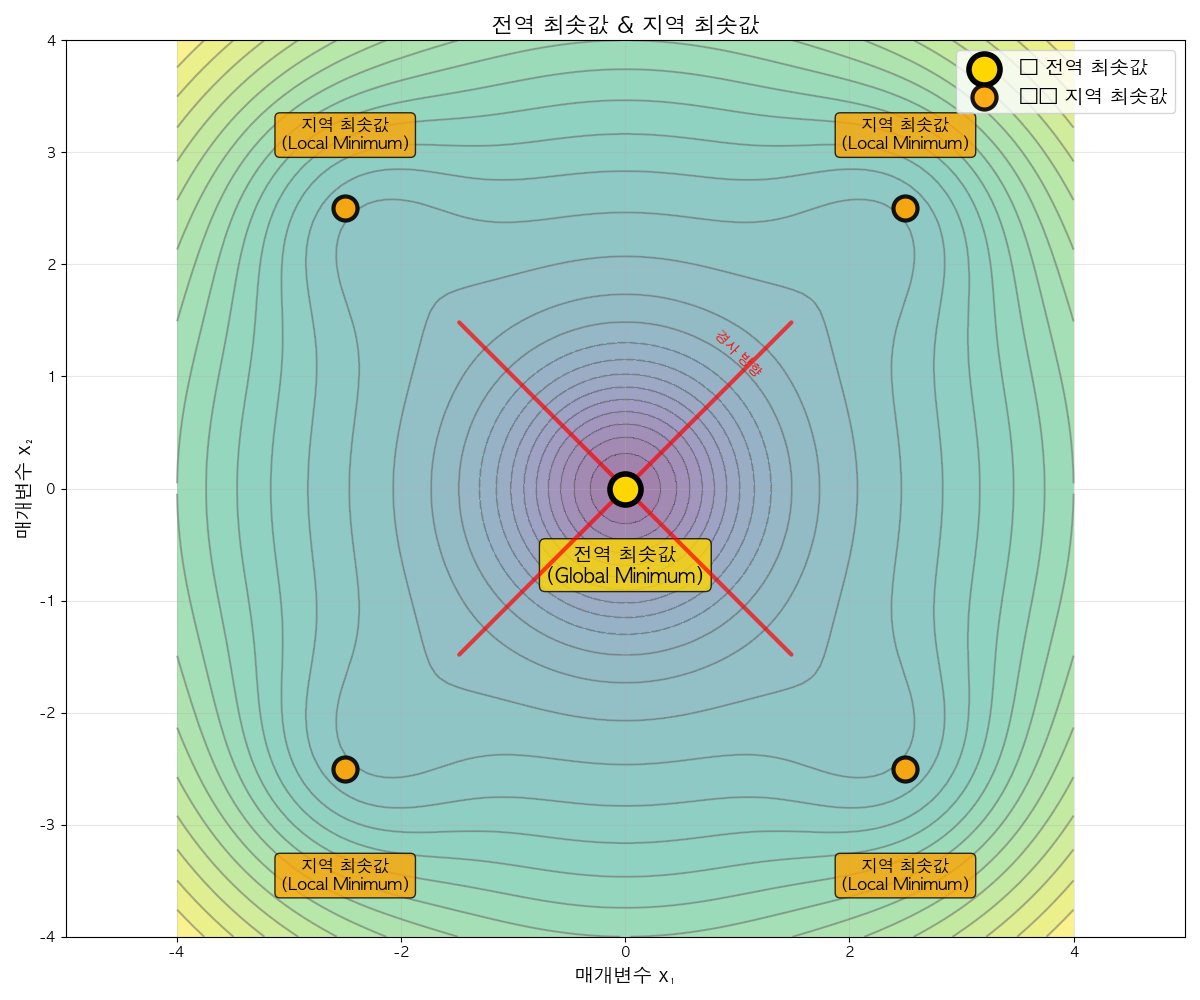

</br>

### 다양한 위치에서 시작 (Random Initialization)
> 여러 번 다른 시작점에서 경사 하강법을 시도하여 가장 낮은 손실 값을 가진 결과를 선택하는 방법입니다.
>
> 시작점이 다르면 도달하는 최솟값도 달라질 수 있기 때문에, 여러 번 시도하여 그 중 가장 좋은 결과를 사용합니다.
임

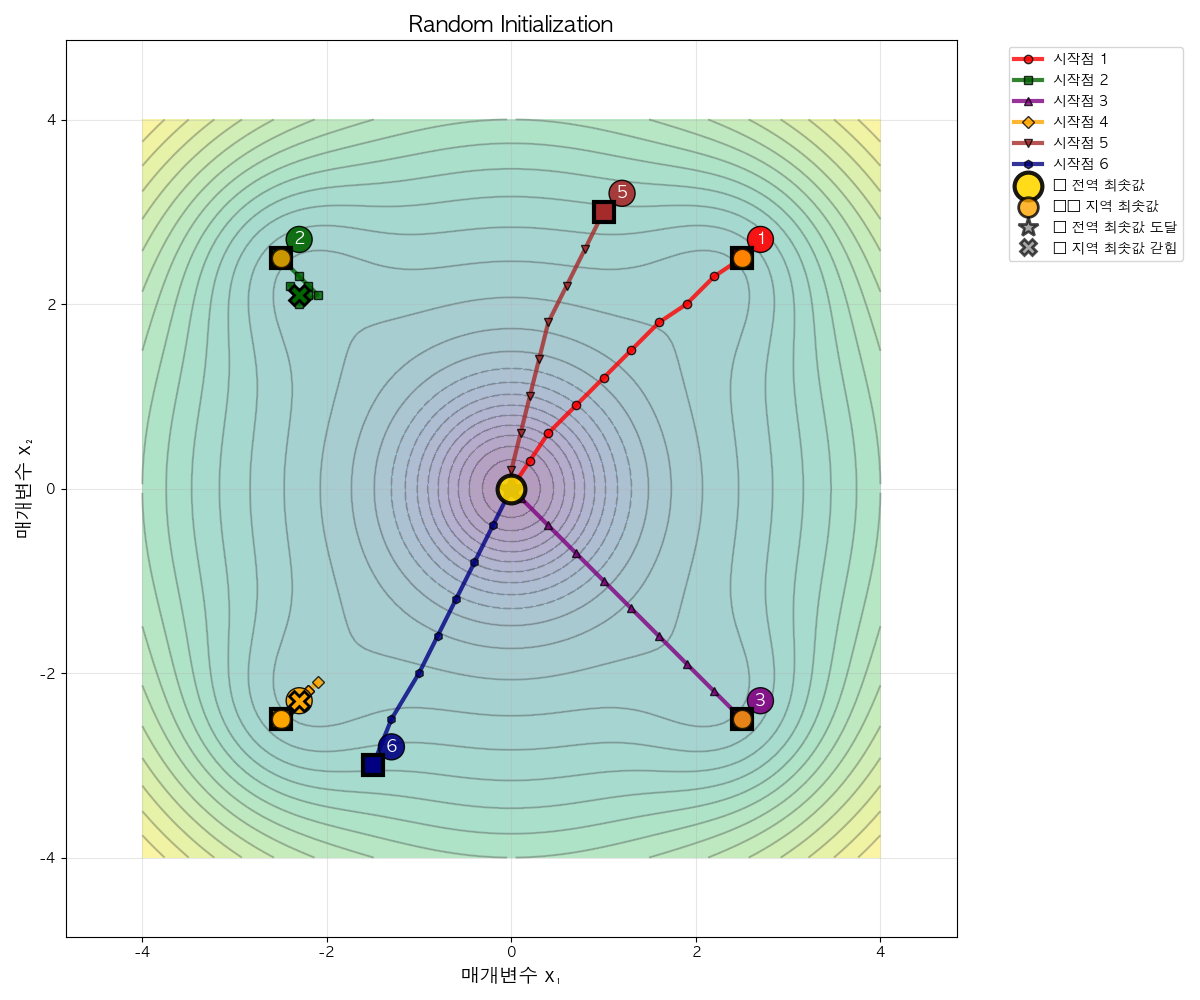

</br>

### 확률적 경사 하강법 (SGD, Stochastic Gradient Descent)
> 전체 데이터 셋 대신 하나의 데이터 샘플을 이용한 방법입니다.
>
> 매번 다른 샘플로 계산하기 때문에 노이즈가 발생하는데, 오히려 이 노이즈가 지역 최솟값에 빠지지 않게 합니다.


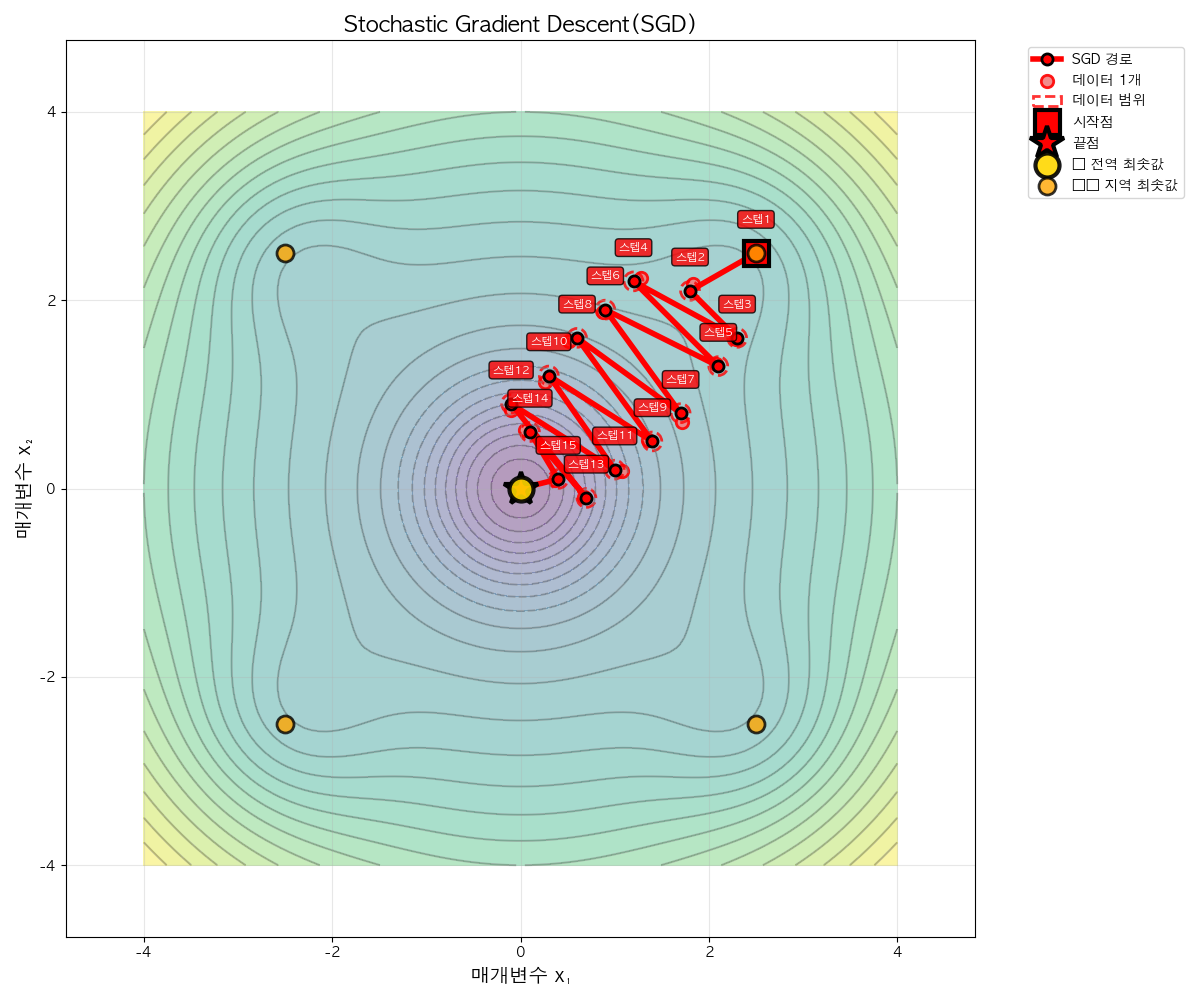

</br>

### 미니 배치 경사 하강법 (MGD, Mini-batch Gradient Descent)
> 전체 데이터를 활용하는 방법을 Batch Gradient Descent라 말하며,
>
> 데이터의 일부(32, 64, 128개 ...)로 나누어 각 배치마다 기울기를 계산하는 방법입니다.

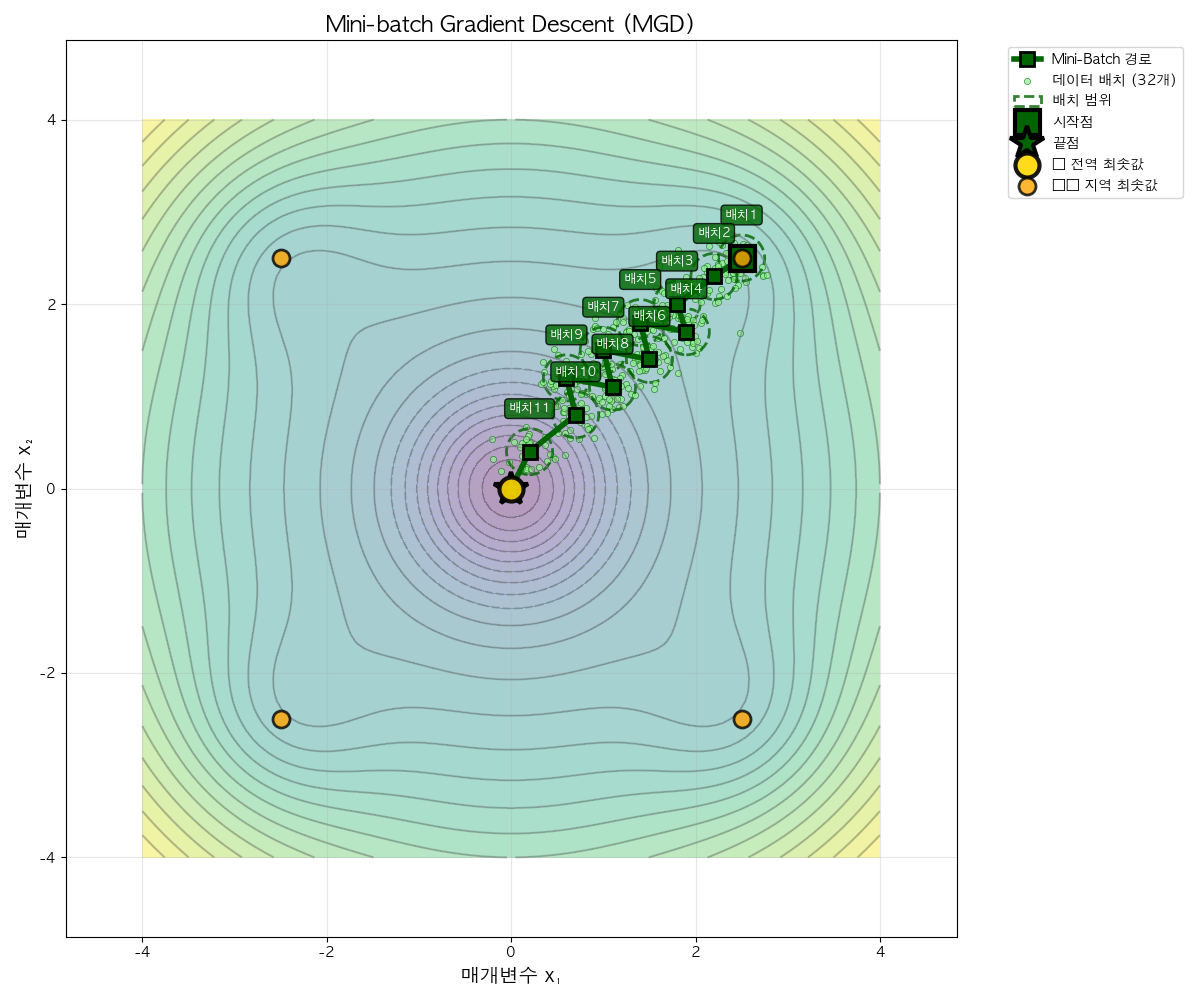

</br>

### 모멘텀 (Momentum)
> 관성 개념을 적용하여 이전 방향을 기억하면서 이동하는 방법입니다.

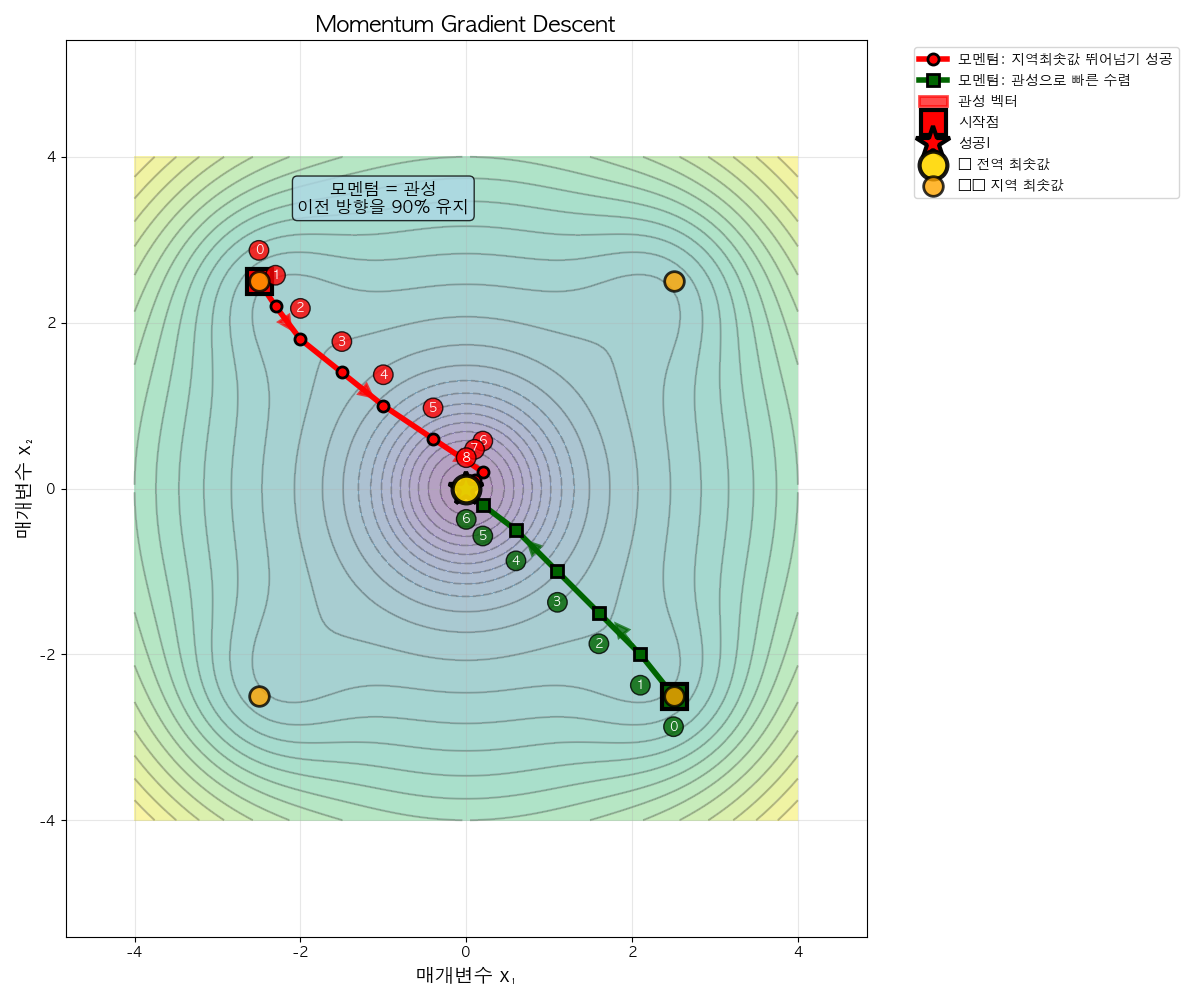

</br>

### 아담 (Adam, Adaptive Moment Estimation)
> 모멘텀과 RMSprop의 장점을 결합한 적응적 학습률 최적화 알고리즘입니다.
>
> 1차 모멘트(방향성), 2차 모멘트(크기)를 활용합니다.

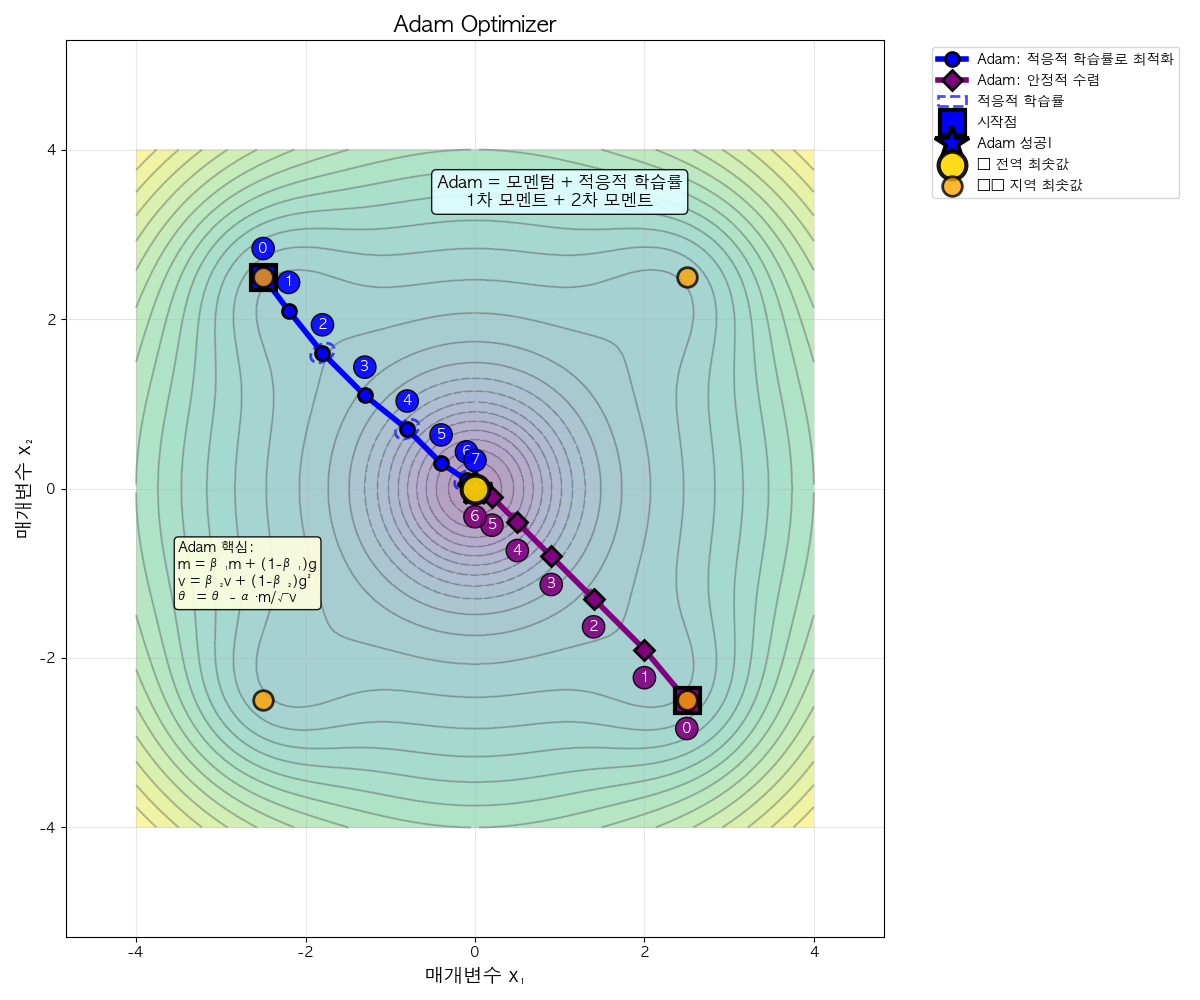